<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Mastering_Scatterplots_in_ggplot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mastering Scatterplots: Visualizing Relationships in R**

### নোটবুক পরিচিতি (Metadata)
- Aim: আর (R) এবং ggplot2 ব্যবহার করে দুটি কন্টিনিউয়াস ভ্যারিয়েবলের মধ্যকার সম্পর্ক এবং প্যাটার্ন বিশ্লেষণ করা শেখা।
- Dataset: বিল্ট-ইন iris ডাটাসেট।
- Key Learnings: Aesthetic Mapping (Color, Size, Shape), Adding Trend Lines, Faceting, এবং Advanced Styling।
- Target: ডেটা সায়েন্স এবং স্ট্যাটিস্টিকসে আগ্রহীদের জন্য একটি কমপ্লিট গাইড।

### কখন স্ক্যাটারপ্লট ব্যবহার করবেন?
- ১. দুটি কন্টিনিউয়াস ভ্যারিয়েবলের মধ্যে সম্পর্ক (যেমন: উচ্চতা বনাম ওজন) দেখতে।
- ২. ডেটায় কোনো কোরিলেশন (পজিটিভ বা নেগেটিভ) আছে কি না তা বুঝতে।
- ৩. আউটলায়ার (Outliers) বা অস্বাভাবিক ডেটা পয়েন্ট খুঁজে বের করতে।
- ৪. একাধিক ডাইমেনশনে ডেটাকে তুলনা করতে (রঙ এবং সাইজ ব্যবহার করে)।

![correlation](https://encrypted-tbn2.gstatic.com/licensed-image?q=tbn:ANd9GcSBF9m97E38tnSUhbt82kYvSJUzqZz03miNrSAx-PqWeCjkLr-lbi4yhvfrXzuvtt-U7AdS9EOqRgeiPozt4ywAGE23SuRss0URVvYzSi446XklEQ4)

### ১. এনভায়রনমেন্ট সেটআপ

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### ২. বেসিক স্ক্যাটারপ্লট (The Foundation)
স্ক্যাটারপ্লটের প্রধান কাজ হলো দুটি অক্ষের (x এবং y) সংযোগস্থলে বিন্দু বসানো।

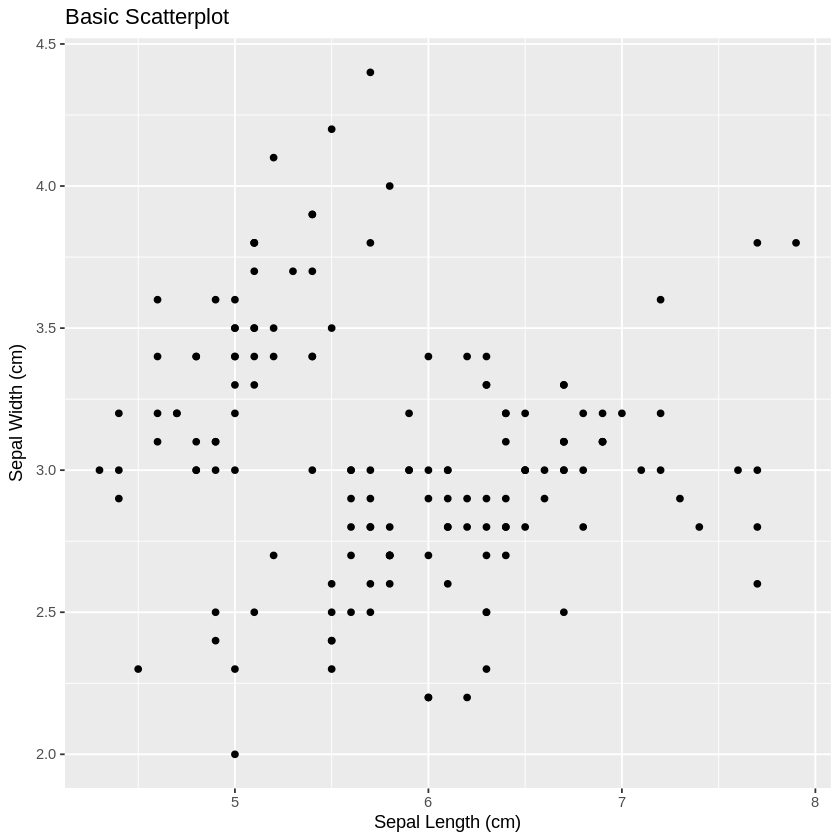

In [2]:
iris %>%
ggplot(aes(x = Sepal.Length, y = Sepal.Width)) +
  geom_point() +
  labs(title = "Basic Scatterplot",
       x = "Sepal Length (cm)",
       y = "Sepal Width (cm)")

**ব্যাখ্যা:** geom_point() হলো স্ক্যাটারপ্লট তৈরির মূল ফাংশন। এটি আমাদের বলে দিচ্ছে সেপাল লেন্থ বাড়লে উইডথ এর কী পরিবর্তন হয়।

### ৩. পয়েন্ট কাস্টমাইজেশন (Styling Points)
বিন্দুগুলোর আকার, আকৃতি এবং স্বচ্ছতা পরিবর্তন করে গ্রাফকে আরও রিডাবল করা যায়।

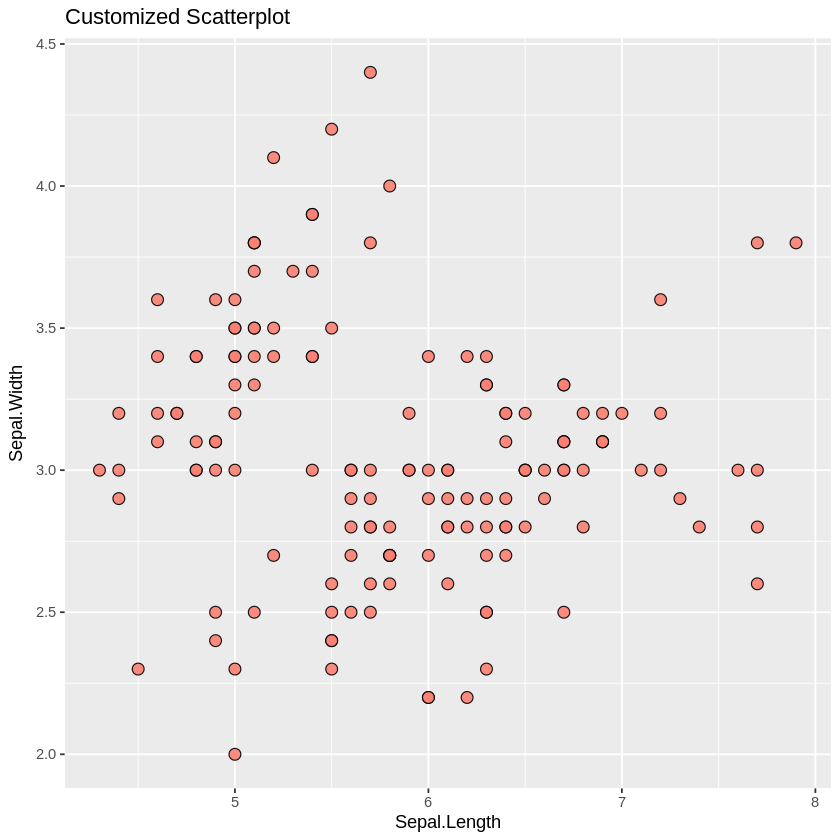

In [3]:
iris %>%
  ggplot(aes(Sepal.Length, Sepal.Width)) +
  geom_point(size = 3,                 # বিন্দুর আকার
             shape = 21,               # ফিল করা যায় এমন বৃত্ত
             color = "black",          # বর্ডার কালার
             fill = "salmon",          # ভেতরের রঙ
             alpha = 0.9) +            # স্বচ্ছতা
  labs(title = "Customized Scatterplot")

### ৪. মাল্টি-ডাইমেনশনাল ম্যাপিং (Advanced Mappings)
আমরা একই গ্রাফে শুধু দুটি নয়, বরং ৩-৪টি ভ্যারিয়েবল দেখাতে পারি।

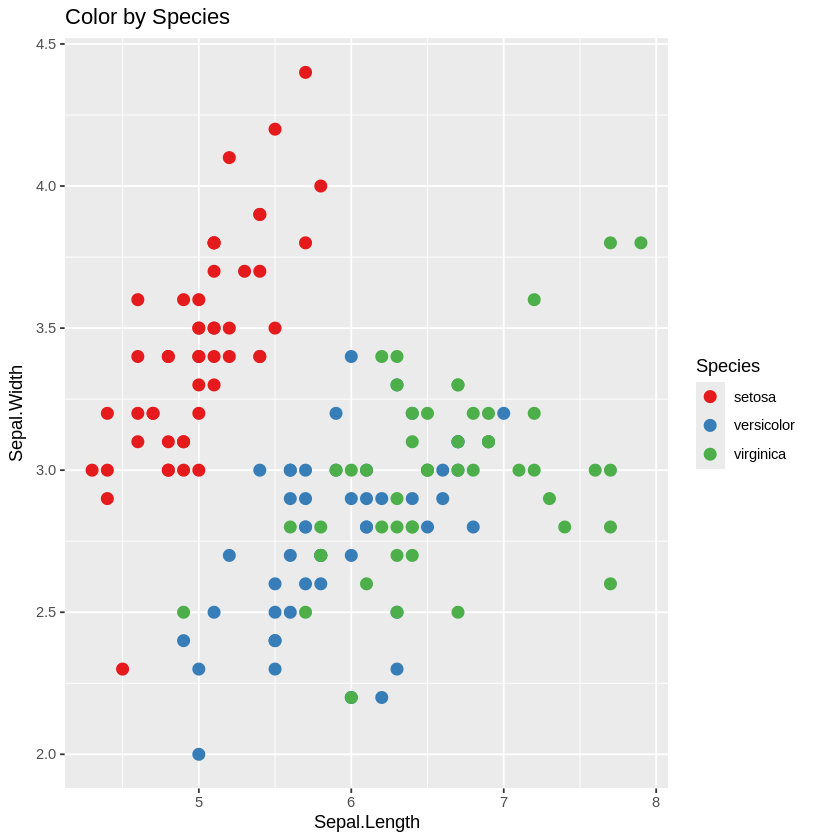

In [4]:
# ক) কালার দিয়ে গ্রুপ আলাদা করা
iris %>%
ggplot(aes(Sepal.Length, Sepal.Width, color = Species)) +
  geom_point(size = 3) +
  scale_color_brewer(palette = "Set1") +
  labs(title = "Color by Species")

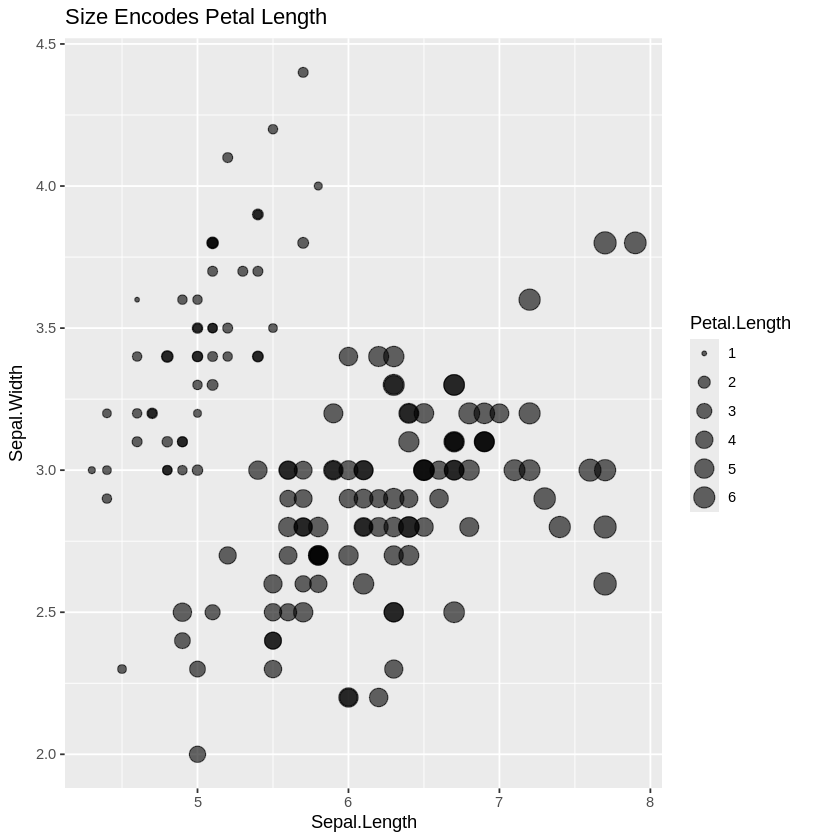

In [5]:
# খ) বিন্দুর সাইজ দিয়ে অন্য ভ্যারিয়েবল দেখানো
iris %>%
ggplot(aes(Sepal.Length, Sepal.Width, size = Petal.Length)) +
  geom_point(alpha = 0.6) +
  labs(title = "Size Encodes Petal Length")

**ব্যাখ্যা:** এখানে রঙের মাধ্যমে প্রজাতি এবং বিন্দুর আকারের মাধ্যমে পেটাল লেন্থ দেখানো হয়েছে। এর ফলে একটি গ্রাফ থেকেই অনেক তথ্য পাওয়া যাচ্ছে।

### ৫. ট্রেন্ড লাইন যোগ করা (Regression Analysis)
ডেটা পয়েন্টগুলোর মধ্য দিয়ে একটি গড় রেখা টানলে কোরিলেশন বোঝা সহজ হয়।

`geom_smooth()` using formula = 'y ~ x'


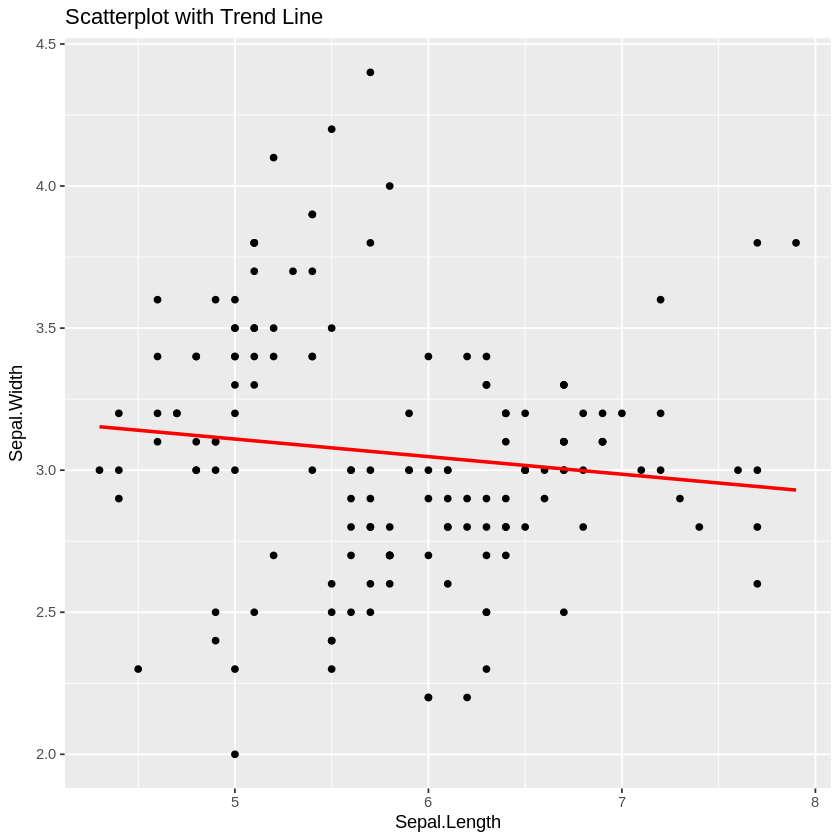

In [6]:
iris %>%
  ggplot(aes(Sepal.Length, Sepal.Width)) +
  geom_point() +
  geom_smooth(method = "lm", color = "red", se = FALSE) + # Linear Model
  labs(title = "Scatterplot with Trend Line")

**ব্যাখ্যা:** geom_smooth(method = "lm") একটি লিনিয়ার রিগ্রেশন লাইন যোগ করে। এটি আমাদের ডেটার সাধারণ গতিপথ বুঝতে সাহায্য করে।

### ৬. ফেসেটিং এবং প্রফেশনাল ফিনিশিং
কখনও কখনও অনেকগুলো গ্রুপকে একসাথে দেখতে হিজিবিজি লাগে, তখন facet_wrap ব্যবহার করা হয়।

`geom_smooth()` using formula = 'y ~ x'


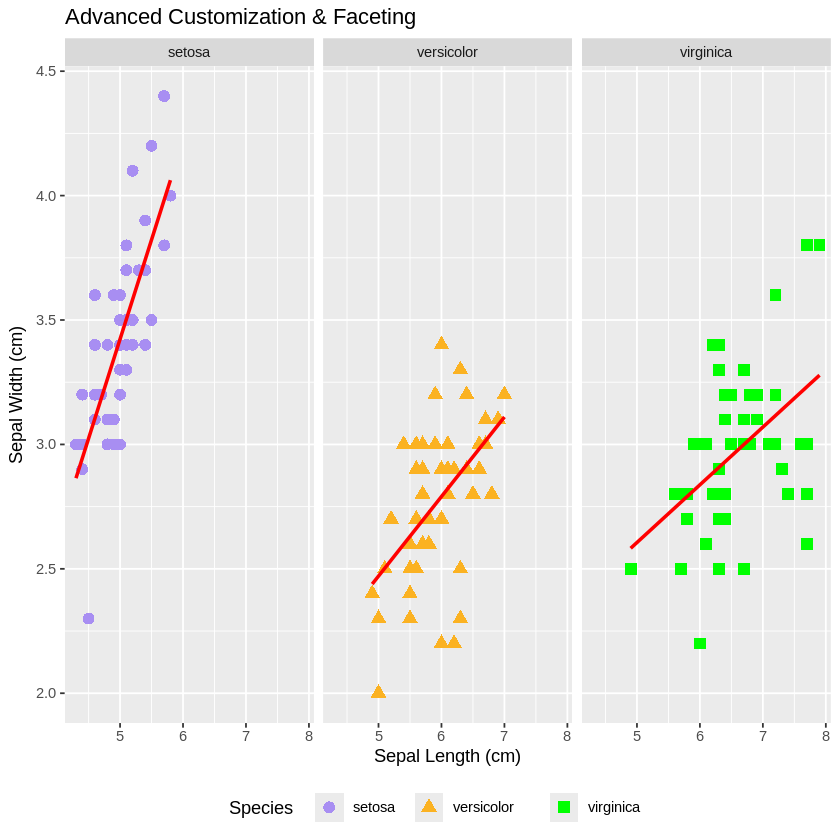

In [7]:
iris %>%
  ggplot(aes(Sepal.Length, Sepal.Width, color = Species, shape = Species)) +
  geom_point(size = 3) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  scale_color_manual(values = c("setosa" = "#A88EF2",
                                "versicolor" = "#FBB222",
                                "virginica" = "green")) +
  facet_wrap(~Species) + # প্রজাতি অনুযায়ী আলাদা গ্রাফ
  labs(title = "Advanced Customization & Faceting",
       x = "Sepal Length (cm)",
       y = "Sepal Width (cm)") +
  theme(legend.position = "bottom")

#### এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):
- geom_point(): বিন্দু বসানোর জন্য।
- color ও shape: ক্যাটাগরিক্যাল ডেটা আলাদা করতে।
- size: কন্টিনিউয়াস ডেটার গুরুত্ব বা পরিমাণ বোঝাতে।
- geom_smooth(): ট্রেন্ড বা প্যাটার্ন লাইন দেখার জন্য।
- facet_wrap(): বড় গ্রাফকে ছোট ছোট অংশে ভাগ করার জন্য।

**অভিনন্দন!** আপনি এখন যে কোনো ডেটাসেট থেকে দুটি ভ্যারিয়েবলের সম্পর্ক বিশ্লেষণ করতে পারবেন।